## Setup

Run this setup cell before starting the notebook.

> In Google Colab, the runtime may restart automatically the first time this cell is executed. If this happens, simply run the same setup cell again.

In [1]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !wget -q https://raw.githubusercontent.com/skleff1994/mpc_tutorial/master/notebooks/colab_setup.py -O /content/colab_setup.py
    %run /content/colab_setup.py
else:
    from pathlib import Path
    import runpy

    cwd = Path.cwd().resolve()

    candidates = [
        cwd / "colab_setup.py",
        cwd / "notebooks" / "colab_setup.py",
        *[p / "notebooks" / "colab_setup.py" for p in cwd.parents],
    ]

    setup_file = next((p for p in candidates if p.is_file()), None)

    if setup_file is None:
        raise RuntimeError("Could not find notebooks/colab_setup.py")

    runpy.run_path(str(setup_file), run_name="__main__")


✅ mpc_tutorial setup complete
Repository root: /home/aboulay/git/auctus_bootcamp/mpc_tutorial
Working directory: /home/aboulay/git/auctus_bootcamp/mpc_tutorial/notebooks
Pinocchio: 3.8.0
Crocoddyl: 3.2.0


# Part 1 : Introduction to Optimal Control
In this first part, we will learn how to optimize robot trajectories.

## Optimal Control Problem (OCP)
At its core, trajectory optimization means: *“Find a sequence of states and controls that achieves a goal while minimizing a cost and respecting the dynamics”*.

Trajectory Optimization can typically be written as an **Optimal Control Problem (OCP)**

\begin{align}
    \min_{\underline{x}, \underline{u}}~ & \sum_{k=0}^{T-1}~ \ell_k(x_k,u_k) + \ell_T(x_T) \\
    &\text{s.t.}~\begin{cases}
                x_0 &= \hat{x}\nonumber \\
                x_{k+1} &= f_k(x_k, u_k) \nonumber \\
                c_k\left(x_k,u_k\right) &\leq 0 \nonumber \\
                c_T\left(x_T\right) &\leq 0 \nonumber
                \end{cases}
\end{align}
where

* $T$ is the horizon length
* $\underline{x}=\{x_0, ..., x_T\}$ is the state trajectory
* $\underline{u}=\{u_0, ..., u_{T-1}\}$ is the control trajectory
* $\ell_k$ is the running cost
* $\ell_T$ is the terminal cost
* $f_k$ is the dynamics constraint
* $c_k$ is the running constraint
* $c_T$ is the terminal constraint

Let's come back to our pendulum to understand what each term of this equation really means in practice.

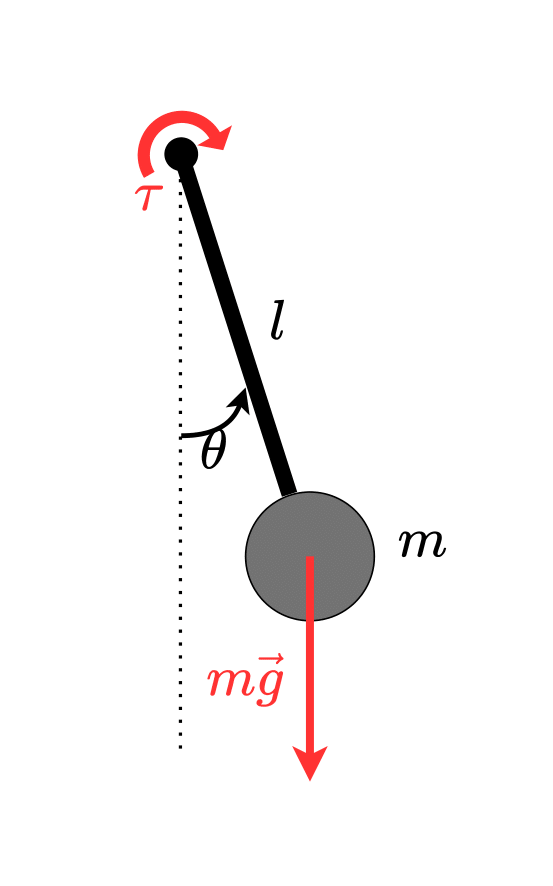

In [2]:
from IPython.display import HTML, Image, display
display(Image(filename=str("../pendulum/pendulum.png"), width=300))

The *state variable $x$* characterizes the motion of the pendulum, i.e. $x_k\triangleq(\theta_k,\dot \theta_k) \in \mathbb{R}^2$ (angular position, angular velocity at time $k$)

The *control variable $u$* is the input action of the system, i.e. $u_k\triangleq\tau_k\in \mathbb{R}$ (motor torque at time $k$)

The control input affects the state evolution according to the discrete dynamics model $x_{k+1} = f_k(x_x,u_k)$ :
\begin{align}
    x_{k+1} = 
    \begin{bmatrix} 
        \theta_{k+1}\\ 
        \dot \theta_{k+1}
    \end{bmatrix} =     \underbrace{\begin{bmatrix} 
                            \theta_k + \dot \theta_{k+1} \Delta t\\
                            \dot \theta_k + \ddot \theta(\theta_k, \tau_k) \Delta t 
                        \end{bmatrix}}_{f_k(x_k,u_k)}
\end{align}
where the angular acceleration $\ddot \theta(\theta_k, \tau_k)$ satisfies Newton's Second Law 
\begin{align}
        ml^2 \ddot\theta (\theta_k, \tau_k) = \tau_k - mgl\sin(\theta_k)
\end{align}

The cost encodes the task : "bring the pendulum to its upward equilibrium $(\theta_{eq}, \dot\theta_{eq}) = (0,0)$ while minimizing the control effort". This is achieved by "penalizing" the distance from the current state to the equilibrium as well as the control input magnitude :
* Running cost $\ell_k(x_k,u_k) = \|\sin(\theta_k)\|^2 + \|1-\cos(\theta_k)\|^2 + \alpha_k\|\dot \theta_k \|^2 + \beta_k \|\tau_k\|^2$ 
* Terminal cost $\ell_T(x) = \|\sin(\theta_T)\|^2 + \|1-\cos(\theta_T)\|^2 + \alpha_T\|\dot \theta_T \|^2$ 

Let's assume that there are no additional constraints for now (no $c_k$, no $c_T$).

## How to solve the OCP ?
There is a key insight: **An OCP is nothing more than a large nonlinear optimization problem (NLP) !**

\begin{align}
    \min_{z}~ & F(z)\\
    &\text{s.t.}~\begin{cases}
                H(z) &= 0\nonumber \\
                G(z) &\leq 0 \nonumber
                \end{cases}
\end{align}

The variables of the NLP are the states and controls $z=(\underline{x},\underline{u})$. The dynamics $f_k$ and constraints $c_k$ simply become nonlinear equality/inequality constraints $H,G$ in the NLP. This perspective is powerful: it allows us to use the whole [toolbox of numerical optimization](https://www.ime.unicamp.br/~pulino/MT404/TextosOnline/NocedalJ.pdf) to solve OCPs. Concretely, for our pendulum, this means that our decision variable is defined as $z = \{\theta_0, \dot \theta_0, \tau_0, ..., u_{T-1}, \theta_T, \dot \theta_T\}$. The functions $F,G,H$ are defined accordingly based on the definition of $\ell_k, f_k, c_k, \ell_T, c_T$. We will not enter the detail of those derivations in this tutorial, but if you are interested you can check out [this paper](https://laas.hal.science/hal-04330251). 

*Remark #1: In practice, there are many ways of "transcripting" optimization problems into OCPs, leading to different "flavors" of optimal control. The approach described above, which we use throughout this tutorial, is called "direct multiple-shooting". You can refer to [this chapter](https://link.springer.com/chapter/10.1007/978-3-540-36119-0_4) for more details.*

*Remark #2: The NLP associated with the original OCP is not just a "random" NLP ; it posseses a **particular structure** that can be exploited to solve it **efficiently**. This is exactly what numerical optimal control solvers do, such as the mim\_solvers library that we will be using today. For more details, see [this paper](https://laas.hal.science/hal-04330251).*

## Interpreting the OCP solution
The solution to the OCP is a set of **optimal state and control trajectories**, i.e. optimal sequences 
* $\underline{x}^\star=\{(\theta_0^\star, \dot \theta_0^\star) ..., (\theta_T^\star, \dot \theta_T^\star)\}$ 
* $\underline{u}^\star=\{\tau_0^\star, ..., \tau_{T-1}^\star\}$

This optimal sequences achieve the lowest cumulated cost $\sum_k \ell_k(x_k,u_k) + \ell_T(x_T)$ while satisfying the dynamics constraint $x_{k+1}=f_x(x_k,u_k)$. 

## How to formulate and solve your first OCP using Crocoddyl

The Crocoddyl library is an optimal control toolbox that allows to define cost functions, dynamics models and constraints like we did for the pendulum, but also for complex robots (e.g. manipulator, humanoid, etc.). The mim\_solvers library is a specialized solver that solves the NLP efficiently using an algorithm called Sequential Quadratic Programming (SQP). 

Each $(x_k,u_k)$ in the horizon is called a *node* (or *stage*). The terminal state $x_T$ is the *terminal node*. In Crocoddyl, OCPs are defined by a sequence of *action models* ; exactly one per node in the horizon. An action model is essentially the cost function, dynamics model and constraint at node $k$, i.e. the triplet $(\ell_k, f_k, c_k)$. The terminal action model is $(\ell_T, c_T)$ (the dynamics does not act on the last state since there is no input).

In order to formulate an OCP of horizon $T$ in Crocoddyl, we must therefore define $T$ action models. Concretely, the action model at node $k$ is implemented as a Python (or C++) class with $2$ main methods : 
* `calc()` method : computes the cost, dynamics and constraint $\ell_k(x_k,u_k), f_k(x_k,u_k), c_k(x_k,u_k)$
* `calcDiff()` method : computes the first- and second-order partial derivatives of the cost, dynamics and constraint, i.e. the Jacobians $\frac{\partial \ell_k}{\partial (x,u)}|_{(x_k,u_k)}$, $\frac{\partial f_k}{\partial (x,u)}|_{(x_k,u_k)}$, $\frac{\partial c_k}{\partial (x,u)}|_{(x_k,u_k)}$ and subsequent Hessians.

In [10]:
import pinocchio as pin
import crocoddyl
import mim_solvers
import numpy
print("✅ Environment ready")

✅ Environment ready


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import crocoddyl
import mim_solvers

from pendulum.pendulum_utils import animatePendulum, plotPendulumSolution


# We define a custom Differential Action Model for the simple pendulum
class DiffActionModelPendulum(crocoddyl.DifferentialActionModelAbstract):
    '''
    This class defines a custom Differential Action Model for the simple pendulum
    It defines the continuous-time
        - dynamics
        - cost
        - constraint
    '''
    def __init__(self, isTerminal=False, dt=0.1):
        self.dt = dt # time step
        self.nq = 1 # number of articulated joints
        self.nv = 1 # number of joint velocities
        self.nx = self.nq + self.nv # dimension of the state 
        self.ndx = 2 # dimension of the tangent space of the state manifold
        nu = 1 # dimension of the control input

        nr = 4 # dimension of the cost-residual vector
        ng = 0 # number of inequality constraints
        nh = 0 # number of equality constraints
        
        # Cost function parameters

        #### Change the cost of the to reach the upright position ####
        if(isTerminal):
            self.costWeights = [
                # to fill, # sin(th) 
                # to fill, # 1-cos(th)
                # to fill, # thdot
                # to fill, # tau
            ]
        else:
            self.costWeights = [
                # to fill, # sin(th)
                # to fill, # 1-cos(th)
                # to fill, # thdot
                # to fill, # tau
            ]
        ##############################################################

        # Create action model
        state = crocoddyl.StateVector(self.nx)
        crocoddyl.DifferentialActionModelAbstract.__init__(self, state, nu, nr, ng, nh)
        self.unone = np.zeros(self.nu) # Neutral state
        
        # Model parameters
        self.g = 9.81
        self.L = 1 
        self.isTerminal = isTerminal

    def calc(self, data, x, u=None):
        if u is None:
            u = self.unone
        s, c = np.sin(x[0]), np.cos(x[0])
        if self.isTerminal:
            # Computing the cost residual and value
            data.r[:] = np.array([s, 1 - c, x[1], u[0]]).T
            data.cost = 0.5 * sum(self.costWeights * (np.asarray(data.r) ** 2)).item()
            data.xout = np.zeros(self.state.nx)
        else:
            # Computing the cost residual and value
            data.r = np.array([s, 1 - c, x[1], u[0]]).T
            data.cost = 0.5 * sum(self.costWeights * (np.asarray(data.r) ** 2)).item()
            data.xout = - self.g * np.sin(x[0]) / self.L + u

    def calcDiff(self, data, x, u=None):
        w = self.costWeights
        s, c = np.sin(x[0]), np.cos(x[0])
        data.Lx[0] = s * ((w[0] - w[1]) * c + w[1])
        data.Lx[1] = w[2] * x[1]
        data.Lxx[0, 0] = w[0] * (c**2 - s**2) + w[1] * (s**2 - c**2 + c)
        data.Lxx[1, 1] = w[2]
        if not self.isTerminal:
            data.Lu[0] = w[3] * u[0]
            data.Luu[0, 0] = w[3]
            data.Fx[0] = - self.g * np.cos(x[0]) / self.L
            data.Fx[1] = 0.
            data.Fu[0] = 1.
        data.Lxu = np.zeros([2, 1])
        if self.isTerminal:
            data.Lx   = self.dt * data.Lx
            data.Lxx =  self.dt * data.Lxx


iter    cost       merit      stop      |grad|      preg       dreg      step   ||ffeas||  ||gfeas||  ||hfeas||   dV-exp       dV      dPhi-exp     dPhi
   0  3.740e-01  0.000e+00  3.813e-01  1.948e-02  1.000e-09  1.000e-09  1.0000  3.000e+00  0.000e+00  0.000e+00 -3.813e-01 -3.640e-01  0.000e+00  0.000e+00
   1  3.740e-01  0.000e+00  4.149e-06  8.298e-06  1.000e-09  1.000e-09  1.0000  0.000e+00  0.000e+00  0.000e+00  4.149e-06  2.565e-06  0.000e+00  0.000e+00
   2  3.740e-01  0.000e+00  4.782e-10  9.563e-10  1.000e-08  1.000e-08  0.0020  0.000e+00  0.000e+00  0.000e+00  1.866e-12 -2.871e-11  0.000e+00  0.000e+00
processing the animation ... 
... processing done


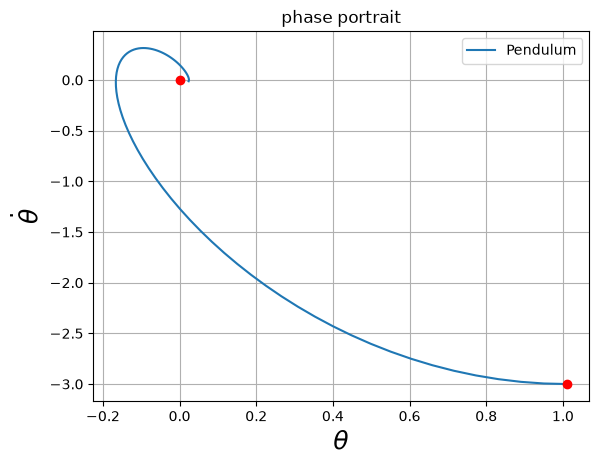

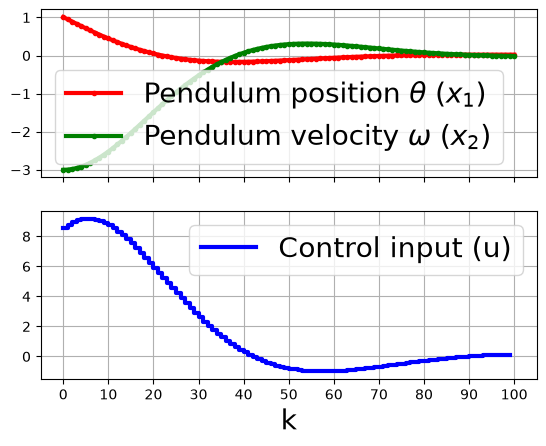

In [ ]:
           
if __name__ == "__main__":
    nx = 2
    nu = 1
    x0 = np.zeros(nx)
    x0[0] = 1+ 0.01 # Initial angle (rad)
    x0[1] = -3 # Initial angular velocity (rad/s)

    # Create the running models
    dt = 2e-2
    T = 100
    running_DAM = DiffActionModelPendulum(isTerminal=False)
    running_model = crocoddyl.IntegratedActionModelEuler(running_DAM, dt)

    running_DAM_terminal = DiffActionModelPendulum(isTerminal=True)
    running_model_terminal = crocoddyl.IntegratedActionModelEuler(running_DAM_terminal, dt)

    # Create the shooting problem
    problem = crocoddyl.ShootingProblem(x0, [running_model] * T, running_model_terminal)


    # # # # # # # # # # # # #
    ###     SOLVE OCP     ###
    # # # # # # # # # # # # #

    # Define warm start
    xs = [x0] * (T + 1) 
    # xs = []
    us = [np.ones(1)] * T

    # Define solver
    # solver = mim_solvers.SolverCSQP(problem)
    # solver = mim_solvers.SolverSQP(problem)
    solver = mim_solvers.SolverCSQP(problem)
    # solver = crocoddyl.SolverFDDP(problem) # required empty list of states + crocoddyl.CallbackVerbose()
    # solver = crocoddyl.SolverDDP(problem) # required empty list of states + crocoddyl.CallbackVerbose()
    solver.termination_tolerance = 1e-4
    solver.with_callbacks = True
    solver.eps_abs = 1e-10
    solver.eps_rel = 0.
    solver.use_filter_line_search = False
    # solver.extra_iteration_for_last_kkt = True
    # Solve
    max_iter = 200
    solver.setCallbacks([mim_solvers.CallbackVerbose()])
    # solver.setCallbacks([crocoddyl.CallbackVerbose()])
    solver.solve(xs, us, max_iter, False)

    # Create animation
    anim = animatePendulum(solver.xs)

    # Plot solution
    plotPendulumSolution(solver.xs, solver.us)

In [11]:
HTML(anim.to_html5_video())